# Importing Libraries and Dataset

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("D:\CreativeIT Class work\Assignments\Dataset lists\mall customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Datset customizations

In [3]:
df = df.rename(columns={"Annual Income (k$)":"income", "Spending Score (1-100)":"score"})

In [4]:
df.head()

,CustomerID,Gender,Age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


To see the relations between two columns we have generated pairplots.

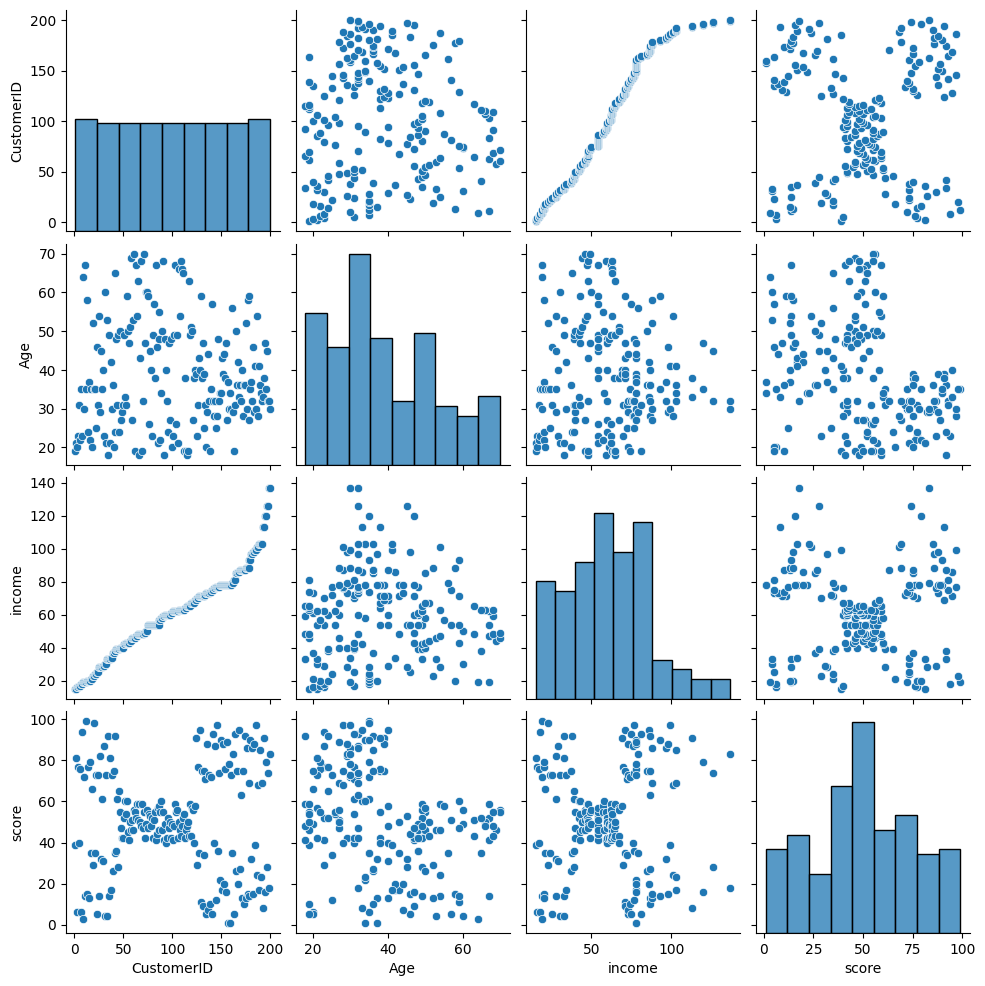

In [5]:
sns.pairplot(df)

# Model Creation
Here we have created a model object and trained it.

In [6]:
# creating object for the model
kmeans= KMeans()

In [7]:
# fitting the model
model = kmeans.fit(df[["income", "score"]])

In [8]:
# prediction by the model
pred = model.predict(df[["income", "score"]])
pred

array([3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5,
       3, 5, 3, 5, 3, 0, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 3, 5, 0, 5, 0, 0,
       3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 0, 4, 0, 0, 4, 4, 0, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 7, 2, 4, 2, 7, 2, 7, 2,
       4, 2, 7, 2, 7, 2, 7, 2, 7, 2, 4, 2, 7, 2, 4, 2, 7, 2, 7, 2, 7, 2,
       7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2, 7, 2,
       7, 2, 7, 2, 1, 2, 1, 2, 1, 2, 1, 6, 1, 6, 1, 6, 1, 6, 1, 6, 1, 6,
       1, 6], dtype=int32)

In [9]:
# create cluster points
clsuter = model.cluster_centers_
clsuter

array([[ 45.51282051,  51.51282051],
       [109.7       ,  22.        ],
       [ 80.375     ,  82.9375    ],
       [ 25.14285714,  19.52380952],
       [ 62.23404255,  47.55319149],
       [ 24.95      ,  81.        ],
       [114.71428571,  78.42857143],
       [ 79.70833333,  14.29166667]])

In [10]:
# create new column called "pred"
df["pred"]= pred

In [11]:
df.head()

,CustomerID,Gender,Age,income,score,pred
0,1,Male,19,15,39,3
1,2,Male,21,15,81,5
2,3,Female,20,16,6,3
3,4,Female,23,16,77,5
4,5,Female,31,17,40,3


In [12]:
# creating new dataframes
df0= df[df["pred"]==0]
df1= df[df["pred"]==1]
df2= df[df["pred"]==2]
df3= df[df["pred"]==3]
df4= df[df["pred"]==4]
df5= df[df["pred"]==5]
df6= df[df["pred"]==6]
df7= df[df["pred"]==7]

In [13]:
df0.head()

,CustomerID,Gender,Age,income,score,pred
27,28,Male,35,28,61,0
40,41,Female,65,38,35,0
42,43,Male,48,39,36,0
43,44,Female,31,39,61,0
45,46,Female,24,39,65,0


# Visualization
Here visualization begins. All the dataframes are being used also all the cluster points are used for this visualization.

<Axes: xlabel='income', ylabel='score'>

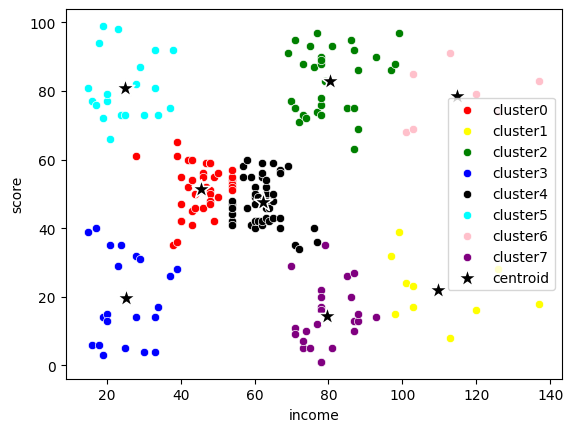

In [14]:
sns.scatterplot(x= df0["income"],y= df0["score"], label="cluster0", color="red")
sns.scatterplot(x= df1["income"], y= df1["score"],label="cluster1", color="yellow")
sns.scatterplot(x= df2["income"],y= df2["score"], label="cluster2", color="green")
sns.scatterplot(x= df3["income"], y= df3["score"],label="cluster3", color="blue")
sns.scatterplot(x= df4["income"],y= df4["score"], label="cluster4", color="black")
sns.scatterplot(x= df5["income"], y= df5["score"],label="cluster5", color="cyan")
sns.scatterplot(x= df6["income"],y= df6["score"], label="cluster6", color="pink")
sns.scatterplot(x= df7["income"], y= df7["score"],label="cluster7", color="purple")

sns.scatterplot(x=clsuter[:,0], y = clsuter[:,1], marker= "*", s= 200, label="centroid", color = "black")

# Elbow Method
Here we used elbow method to find the right no of clusters

In [15]:
# elbow method 
wcss = []
cluster_num = range(2,20)
for k in cluster_num:
    print("value of k is  ", k)
    new_model = KMeans(n_clusters=k)
    model2 = new_model.fit(df[["income", "score"]])
    wcss.append(model2.inertia_)
    

value of k is   2
value of k is   3
value of k is   4
value of k is   5
value of k is   6
value of k is   7
value of k is   8
value of k is   9
value of k is   10
value of k is   11
value of k is   12
value of k is   13
value of k is   14
value of k is   15
value of k is   16
value of k is   17
value of k is   18
value of k is   19


In [16]:
wcss

[183653.32894736843,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37558.92202302528,
 32227.558007109168,
 30666.26213098212,
 26420.994268372524,
 26282.95526304025,
 19704.503618583796,
 16055.116776072377,
 14917.213079676312,
 14654.126608079847,
 12817.393627036918,
 12344.878103378098,
 11731.75431034483,
 9604.470386557885,
 8754.682587575262]

## Visualization of the Elbow Method

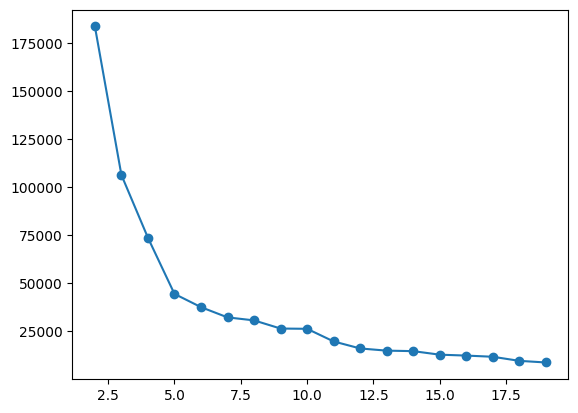

In [17]:
plt.plot(cluster_num, wcss, marker="o")

### Installing Module

In [18]:
!pip install kneed

In [19]:
import kneed
from kneed import KneeLocator

In [20]:
knl = KneeLocator(cluster_num, wcss, curve= "convex", direction="decreasing")

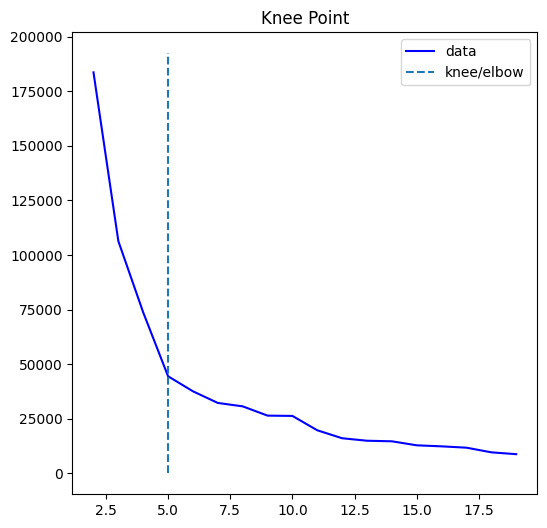

In [21]:
knl.plot_knee()

# Assignment
**Part 1: K-Means Clustering and Visualization**

* **Train the Model:** Train your K-Means clustering model with the number of clusters (k) set to 5.

* **Find Centroids:** Calculate and locate the cluster centroids for all 5 clusters.

* **Update Dataset:** Add the predicted cluster values (0, 1, 2, 3, and 4) as a new column to your existing dataset.

* **Create Separate DataFrames:** Filter your dataset to create 5 separate dataframes, one for each specific cluster value (from 0 to 4).

* **Visualize:** Recreate the visualization shown in the video, plotting the clustered data points and highlighting the centroids.

**Part 2: New Data Point Prediction**

* **Take User Input:** Write code to accept a new score and a new income value from the user.

* **Predict Cluster:** Feed this new data point (score and income) into your trained model to predict which of the 5 clusters it belongs to.

* **Visualize the New Point:** Add this newly input data point to your existing scatter plot using plt.scatter. Give it a distinct color so it stands out from the rest of the clustered data.

* **Show Result:** Clearly display or print the specific cluster number that the model predicted for this new data point.

# Object Creation of the model
new object has been created for the Kmeans() with constraints from the previous analysis.

In [22]:
new_kmean = KMeans(n_clusters = 5, random_state= 42)

# Fitting the model

In [23]:
new_model = new_kmean.fit(df[["income", "score"]])

# Finding new centroids

In [24]:
new_centroids = new_model.cluster_centers_
print("Centroids \n(Income, Score):\n", new_centroids)

Centroids 
(Income, Score):
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


we have dropped the "pred" column.

In [25]:
df = df.drop(columns= 'pred', axis=1)
df.head()

,CustomerID,Gender,Age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [26]:
# checking columns
df.columns

Index(['CustomerID', 'Gender', 'Age', 'income', 'score'], dtype='object')

# Create new column
Creating new column called "cluster"

In [27]:
df["cluster"] = new_model.predict(df[["income", "score"]])
df.head()

,CustomerID,Gender,Age,income,score,cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Creating 5 seperate datapoints

In [28]:
df0 = df[df["cluster"] == 0]
df1 = df[df["cluster"] == 1]
df2 = df[df["cluster"] == 2]
df3 = df[df["cluster"] == 3]
df4 = df[df["cluster"] == 4]

# Visualization of the Assignment

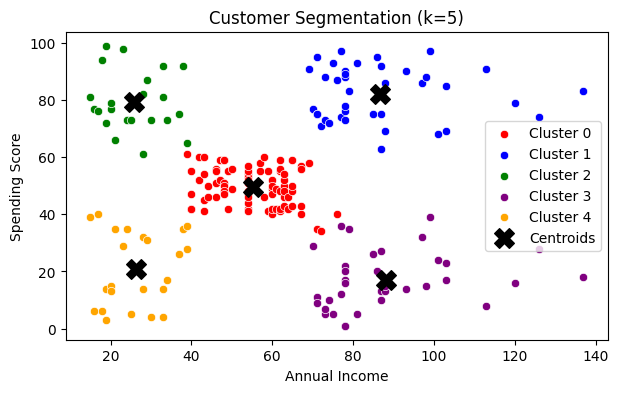

In [29]:
# declaring fig size
plt.figure(figsize=(7, 4))

# Plotting the clustered data points
sns.scatterplot(x=df0["income"], y=df0["score"], label="Cluster 0", color="red")
sns.scatterplot(x=df1["income"], y=df1["score"], label="Cluster 1", color="blue")
sns.scatterplot(x=df2["income"], y=df2["score"], label="Cluster 2", color="green")
sns.scatterplot(x=df3["income"], y=df3["score"], label="Cluster 3", color="purple")
sns.scatterplot(x=df4["income"], y=df4["score"], label="Cluster 4", color="orange")

# Plotting the centroids
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], color="black", marker="X", s=200, label="Centroids")

plt.title("Customer Segmentation (k=5)")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()

# New Datapoint prediction
New datapoint prediction by taking inputs from the user.

In [30]:
# user input
new_income = float(input("Enter the new Annual Income (k$): "))
new_score = float(input("Enter the new Spending Score (1-100): "))

# Create new dataframe from the user input
new_data = pd.DataFrame([[new_income, new_score]], columns=["income", "score"])

Enter the new Annual Income (k$):  16
Enter the new Spending Score (1-100):  6


new datas then being pushed to the model for prediction.

In [31]:
# Cluster prediction
predicted_cluster = new_model.predict(new_data)[0]

# checking the result
print(f"Result\nThe model predicts this new customer belongs to Cluster: {predicted_cluster}")

Result
The model predicts this new customer belongs to Cluster: 4


## Visualization of the new point inputted by user

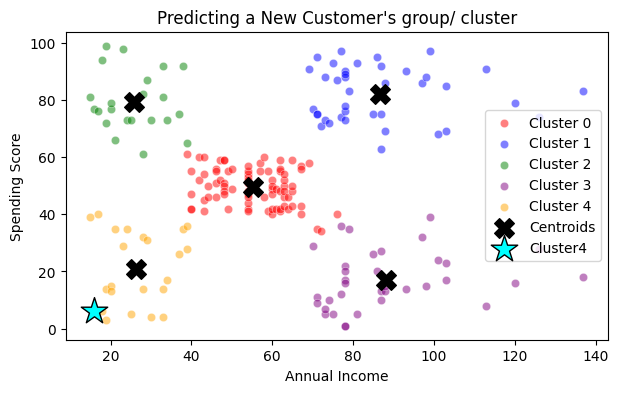

In [36]:
# declaring fig size
plt.figure(figsize=(7, 4))

# Plotting the clustered data points
sns.scatterplot(x=df0["income"], y=df0["score"], label="Cluster 0", color="red", alpha=0.5)
sns.scatterplot(x=df1["income"], y=df1["score"], label="Cluster 1", color="blue", alpha=0.5)
sns.scatterplot(x=df2["income"], y=df2["score"], label="Cluster 2", color="green", alpha=0.5)
sns.scatterplot(x=df3["income"], y=df3["score"], label="Cluster 3", color="purple", alpha=0.5)
sns.scatterplot(x=df4["income"], y=df4["score"], label="Cluster 4", color="orange", alpha=0.5)
# Plotting the centroids
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], color="black", marker="X", s=200, label="Centroids")

# predicted cluster is saved in a variable
labels = f"Cluster{predicted_cluster}"

# Plot the NEW data point
plt.scatter(new_income, new_score, color="cyan", marker="*", s=400, edgecolor="black", label=labels)

# graph details
plt.title("Predicting a New Customer's group/ cluster")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()
plt.show()